$
\def\D{\Omega}
\def\ipar{m}
\def\R{\mathbb{R}}
\def\vec{\bf}
\def\priorm{\mu_0}
\def\C{\mathcal{C}}
\def\Acal{\mathcal{A}}
\def\postm{\mu_{\rm{post}}}
\def\iparpost{\ipar_\text{post}}
\def\obs{ {\vec d}}
\def\obsop{\mathcal{B}}
\def\iFF{\mathcal{F}}
\def\iFFadj{\mathcal{F}^*}
\def\ncov{\Gamma_{\mathrm{noise}}}
$
# Bayesian initial condition inversion in an advection-diffusion problem

In this example we tackle the problem of quantifying the uncertainty in the solution of an
inverse problem governed by a parabolic PDE via the Bayesian inference framework. The
underlying PDE is a time-dependent advection-diffusion equation in which we seek to infer
an unknown initial condition from spatio-temporal point measurements.

## The Bayesian inverse problem:

Following the Bayesian framework, we utilize a Gaussian prior measure
$\priorm = \mathcal{N}(\ipar_0,\C_0)$, with $\C_0=\Acal^{-2}$ where $\Acal$ is an elliptic
differential operator as described in the subsurface Bayesian example, and use an additive
Gaussian noise model. Therefore, the solution of the Bayesian inverse problem is the
posterior measure, $\postm = \mathcal{N}(\iparpost,\C_\text{post})$ with $\iparpost$ and
$\C_\text{post}$.

- The posterior mean $\iparpost$ is characterized as the minimizer of

$$ \mathcal{J}(\ipar) := \frac{1}{2} \left\| \obsop u(\ipar) -\obs \right\|^2_{\ncov^{-1}} + \frac 12 \left\| \Acal(\ipar - \ipar_0) \right\|^2_{L^2(\D)}, $$

which can also be interpreted as the regularized functional to be minimized in
deterministic inversion. The observation operator $\mathcal{B}$ extracts the values of the
forward solution $u$ on a set of locations $\{{\vec{x}}_1, \ldots, {\vec{x}}_n\} \subset \D$
at times $\{t_1, \ldots, t_N\} \subset [0, T]$.

- The posterior covariance $\C_{\text{post}}$ is the inverse of the Hessian of $\mathcal{J}(\ipar)$, i.e.,

$$ \C_{\text{post}} = (\iFFadj \ncov^{-1} \iFF + \C_0^{-1})^{-1}. $$

## The forward problem:

The parameter-to-observable map $\iFF \,\ipar := \obsop\, u(\ipar)$ maps an initial
condition $\ipar \in L^2(\D)$ to pointwise spatiotemporal observations of the
concentration field $u({\vec x},t)$ through the solution of the advection-diffusion
equation

$$
\begin{aligned}
u_t - \kappa\Delta u + {\vec v} \cdot \nabla u &= 0 && \text{in } \D\times(0,T),\\
u(\cdot, 0) &= \ipar && \text{in } \D,\\
\kappa \nabla u\cdot {\vec{n}} &= 0 && \text{on } \partial\D \times (0,T).
\end{aligned}
$$

Here, $\D = (0, 1)^2$, $\kappa > 0$ is the diffusion coefficient and $T > 0$ is the final
time. The velocity field is a steady, divergence-free vortex given by a stream function,

$$ {\vec v} = \left( \frac{\partial \psi}{\partial y}, -\frac{\partial \psi}{\partial x} \right),
\qquad \psi(x, y) = \frac{1}{\pi} \sin^2(\pi x) \sin^2(\pi y), $$

which is tangential to the walls (${\vec v} \cdot {\vec n} = 0$) and has unit maximum speed.

hIPPYlib's version of this tutorial computes the velocity by solving the steady
Navier-Stokes equations in a domain with two obstacles, driven by the side walls, and
stabilizes the transport with SUPG at $\kappa = 0.001$. The Navier-Stokes solve needs a
mixed velocity-pressure space, which hIPPyMFEM does not support, so here the flow is
prescribed; and we take $\kappa = 0.01$, at which the Galerkin discretization needs no
stabilization on this mesh.

## The adjoint problem:

The adjoint problem is a final value problem, since $p$ is specified at $t = T$ rather
than at $t = 0$. Thus, it is solved backwards in time, which amounts to the solution of
the advection-diffusion equation

$$
\begin{aligned}
-p_t - \nabla \cdot (p {\vec v}) - \kappa \Delta p &= -\obsop^* (\obsop u - \obs) && \text{in } \D\times (0,T),\\
p(\cdot, T) &= 0 && \text{in } \D,\\
({\vec{v}}p+\kappa\nabla p)\cdot {\vec{n}} &= 0 && \text{on } \partial\D\times (0,T).
\end{aligned}
$$

Then, the adjoint of the parameter to observable map $\iFF^*$ is defined by setting
$\iFF^*\obs = p({\vec x}, 0).$

## In hIPPyMFEM

The time-dependent problem is written as one implicit Euler step, a density of the new
and the old state,

$$ r(u_n, u_{n-1}, m, p; x, t, \Delta t) = \frac{u_n - u_{n-1}}{\Delta t}\, p + \kappa\, \nabla u_n \cdot \nabla p + ({\vec v} \cdot \nabla u_n)\, p, $$

and `TimeDependentPDEVariationalProblem` marches it forward, marches the adjoint backward,
and applies the space-time Hessian. The parameter enters only through the initial
condition; the wrapper that makes it do so, `InitialConditionProblem`, lives with the
application in `applications/ad_diff`, as hIPPYlib's `TimeDependentAD` does.

## 1. Load modules

In [1]:
import math
import os
import sys

base = os.environ.get("HIPPYMFEM_BASE_DIR", os.path.abspath(".."))
sys.path.insert(0, base)
sys.path.insert(0, os.path.join(base, "applications", "ad_diff"))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from mpi4py import MPI
import mfem.par as mfem

import hippymfem as hm
from hippymfem import nb, STATE, PARAMETER, ADJOINT

import jax.numpy as jnp

from model_ad_diff import InitialConditionProblem

mfem.Hypre.Init()
comm = MPI.COMM_WORLD

## 2. Construct the velocity field

The velocity is written once, with an array module argument, so the same expression is
evaluated by JAX inside the density and by NumPy for the plot.

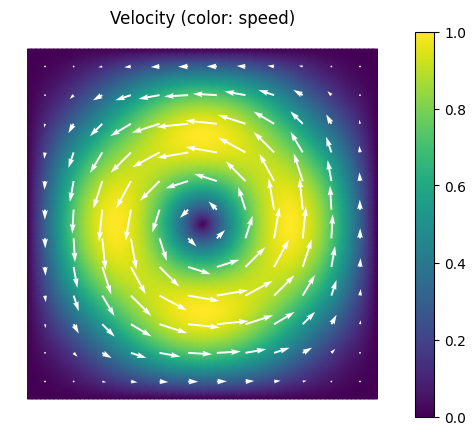

In [2]:
def velocity(x, xp=jnp):
    # v = (d psi/dy, -d psi/dx) for psi = sin^2(pi x) sin^2(pi y) / pi
    return xp.array([xp.sin(xp.pi * x[0]) ** 2 * xp.sin(2 * xp.pi * x[1]),
                     -xp.sin(2 * xp.pi * x[0]) * xp.sin(xp.pi * x[1]) ** 2])


nx = 40
mesh = mfem.ParMesh(comm, mfem.Mesh.MakeCartesian2D(nx, nx, mfem.Element.TRIANGLE))

Vv = hm.FunctionSpace.H1(mesh, 2, vdim=2)
v_field = Vv.project(lambda x: velocity(x, xp=np))
X, Y = np.meshgrid(np.linspace(0.05, 0.95, 12), np.linspace(0.05, 0.95, 12))
VX, VY = velocity(np.array([X, Y]), xp=np)

plt.figure(figsize=(6.5, 5))
nb.plot(Vv, v_field, mytitle="Velocity (color: speed)")
plt.quiver(X, Y, VX, VY, color="w")
plt.show()

## 3. Set up the mesh and finite element spaces

In [3]:
Vh = hm.FunctionSpace.H1(mesh, 1)
print("Number of dofs: {0}".format(Vh.GlobalTrueVSize()))

Number of dofs: 1681


## 4. Set up model (prior, true/proposed initial condition)

The misfit is a sum over the observed time levels, `MisfitTD`, of one pointwise misfit per
level. The walls are insulated, so there are no Dirichlet conditions (`None`).

Number of observation points: 80


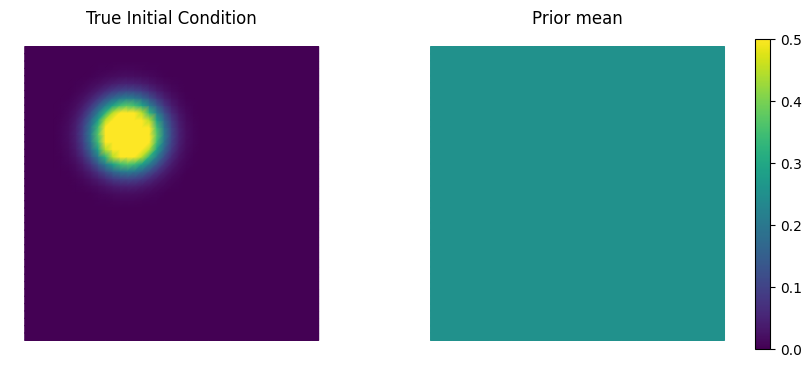

In [4]:
true_initial_condition = Vh.project(
    lambda x: min(0.5, math.exp(-100.0 * ((x[0] - 0.35) ** 2 + (x[1] - 0.7) ** 2))))
gamma = 1.0
delta = 8.0
prior = hm.BiLaplacianPrior(Vh, gamma, delta, robin_bc=True,
                            mean=Vh.project(lambda x: 0.25))

t_init = 0.0
t_final = 4.0
t_1 = 1.0
dt = 0.1
observation_dt = 0.2
kappa = 0.01


def varf(u, u_old, m, p, x, t, dt):
    return ((u.val - u_old.val) / dt * p.val
            + kappa * hm.inner(u.grad, p.grad)
            + jnp.dot(velocity(x), u.grad) * p.val)


pde = hm.TimeDependentPDEVariationalProblem([Vh, Vh, Vh], varf, None, None, Vh.vector(),
                                            t_init, t_final, dt, is_fwd_linear=True,
                                            quadrature_degree=4)
for attr in ("solver", "solver_fwd_inc", "solver_adj_inc"):
    setattr(pde, attr, hm.auto_solver(Vh, comm, method="gmres"))
problem = InitialConditionProblem(pde)

simulation_times = pde.times
observation_times = np.arange(t_1, t_final + 0.5 * dt, observation_dt)

rng = np.random.default_rng(1)
targets = rng.uniform(0.1, 0.9, size=(80, 2))
print("Number of observation points: {0}".format(targets.shape[0]))
B = hm.assemblePointwiseObservation(Vh, targets)
misfits = [hm.DiscreteStateObservation(B, B.createVecLeft(), 1.0)
           if np.any(np.isclose(t, observation_times)) else None
           for t in simulation_times]
misfit = hm.MisfitTD(misfits, simulation_times)

model = hm.Model(problem, prior, misfit)

nb.multi1_plot([(Vh, true_initial_condition), (Vh, prior.mean)],
               ["True Initial Condition", "Prior mean"])
plt.show()

## 5. Generate the synthetic observations

One noise level for the whole data set, one percent of the largest observed value.

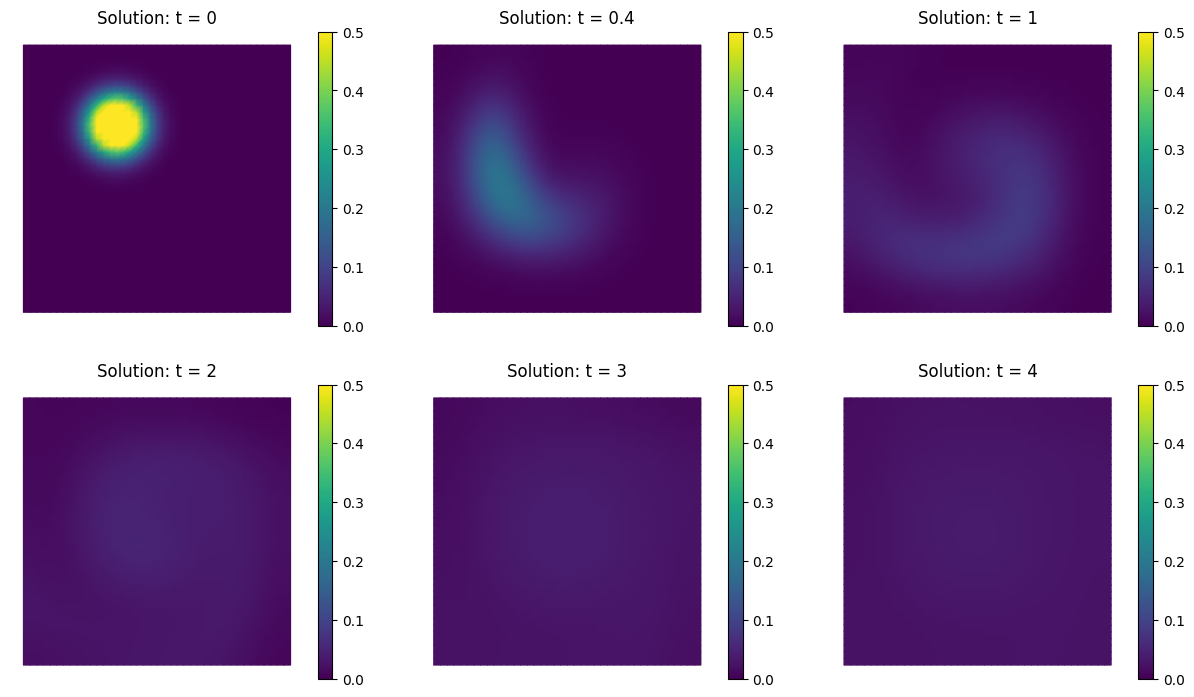

In [5]:
rel_noise = 0.01
utrue = problem.generate_state()
x = [utrue, true_initial_condition, None]
problem.solveFwd(x[STATE], x)

observed = [(t, mis) for t, mis in zip(simulation_times, misfits) if mis is not None]
for t, mis in observed:
    B.mult(utrue.view(t), mis.d)
MAX = max(mis.d.norm("linf") for t, mis in observed)
noise_std_dev = rel_noise * MAX
hm.parRandom.set_seed(1)
for t, mis in observed:
    B.perturb(mis.d, noise_std_dev)
    mis.noise_variance = noise_std_dev ** 2

nb.show_solution(Vh, true_initial_condition, utrue, mytitle="Solution")
plt.show()

## 6. Test the gradient and the Hessian of the cost (negative log posterior)

The cost is quadratic in the initial condition, so the finite-difference error of the
Hessian action is round-off at every step.

      eps  ||err grad||     ||err H||        J(m+h)       slope g


 1.00e+00  7.147589e+07  2.020679e-07  7.148994e+07             -


 5.00e-01  3.573794e+07  1.995650e-07  1.787685e+07        1.0000


 2.50e-01  1.786897e+07  1.956651e-07  4.472041e+06        1.0000


 1.25e-01  8.934486e+06  1.899753e-07  1.120066e+06        1.0000


...

 3.73e-09  2.662503e-01  2.971947e-03  1.713282e+03        0.9999


 1.86e-09  1.328885e-01  6.557917e-03  1.713282e+03        1.0026


 9.31e-10  6.611603e-02  1.287723e-02  1.713282e+03        1.0071


 4.66e-10  3.095978e-02  2.383591e-02  1.713282e+03        1.0946


Quadratic cost: the Hessian error should be ~0 everywhere: yes


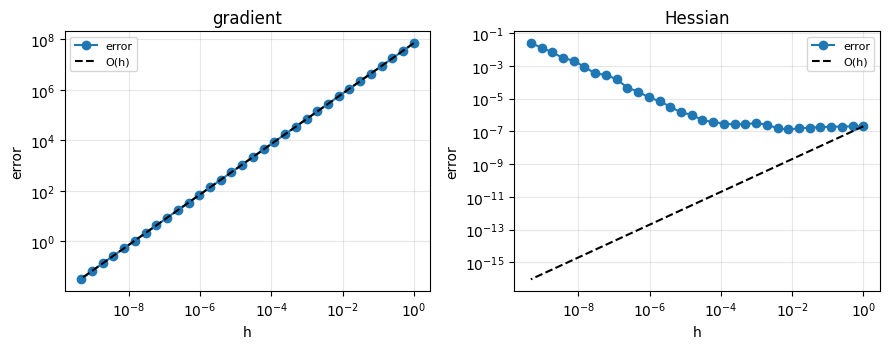

In [6]:
m0 = true_initial_condition.copy()
_ = hm.modelVerify(model, m0, is_quadratic=True, plotting=True)
plt.show()

## 7. Evaluate the gradient

In [7]:
u = model.generate_vector(STATE)
m = model.generate_vector(PARAMETER)
p = model.generate_vector(ADJOINT)
model.solveFwd(u, [u, m, p])
model.solveAdj(p, [u, m, p])
mg = model.generate_vector(PARAMETER)
grad_norm = model.evalGradientParameter([u, m, p], mg)

print("||g|| = ", grad_norm)

||g|| =  61567740.52505007


## 8. The Gaussian posterior

The problem is linear in the initial condition, so the Gauss-Newton Hessian is the Hessian
and it does not depend on the point: it is built once, here at $m = 0$. A single-pass
randomized eigensolver gives its low-rank factorization.

Single Pass Algorithm. Requested eigenvectors: 80; Oversampling 20.


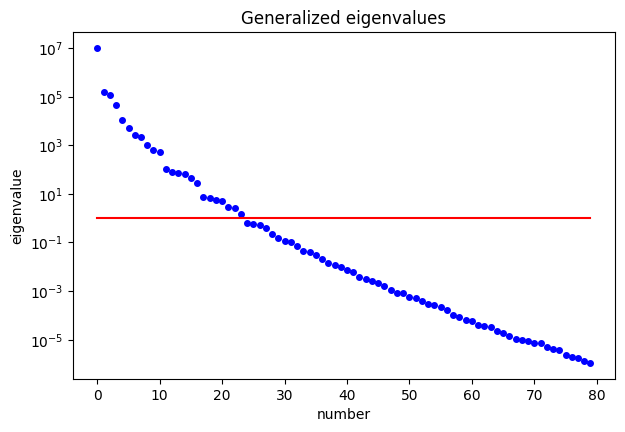

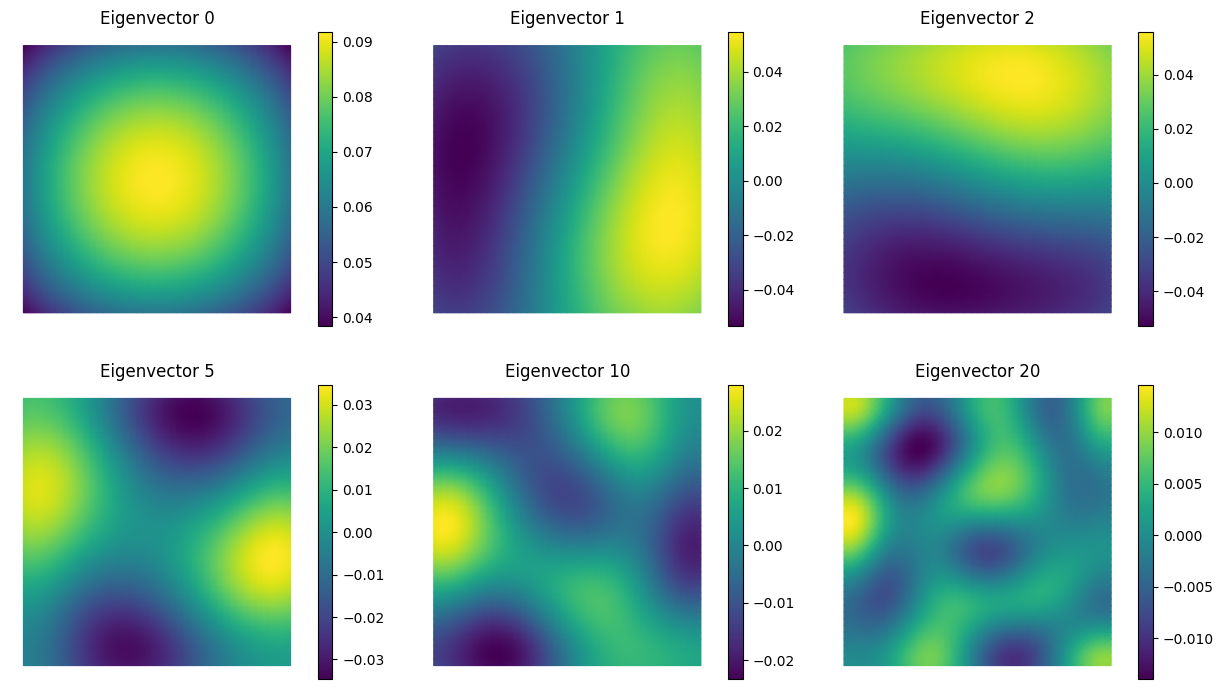

In [8]:
model.setPointForHessianEvaluations([u, m, p], gauss_newton_approx=True)
H = hm.ReducedHessian(model, misfit_only=True)

k = 80
p_over = 20
print("Single Pass Algorithm. Requested eigenvectors: {0}; Oversampling {1}.".format(k, p_over))
Omega = hm.MultiVector(m, k + p_over)
hm.parRandom.normal_multivector(1.0, Omega)
lmbda, V = hm.singlePassG(H, prior.R, prior.Rsolver, Omega, k)

posterior = hm.GaussianLRPosterior(prior, lmbda, V)

plt.figure(figsize=(7, 4.5))
nb.plot_eigenvalues(lmbda, mytitle="Generalized eigenvalues")
nb.plot_eigenvectors(Vh, V, mytitle="Eigenvector", which=[0, 1, 2, 5, 10, 20])
plt.show()

## 9. Compute the MAP point

For a quadratic cost one Newton step from any point is the minimizer. The Newton system
is solved by CG preconditioned with the low-rank posterior covariance just computed, which
leaves CG only the part of the spectrum the eigensolver did not capture.

   CG   0  (B r, r) = 2.086654e+06


   CG   1  (B r, r) = 1.400049e-06


 Relative/Absolute residual less than tol


 Converged in 1 iterations with final norm 1.183237e-03


Total cost 669.936; Reg Cost 62.0819; Misfit 607.854


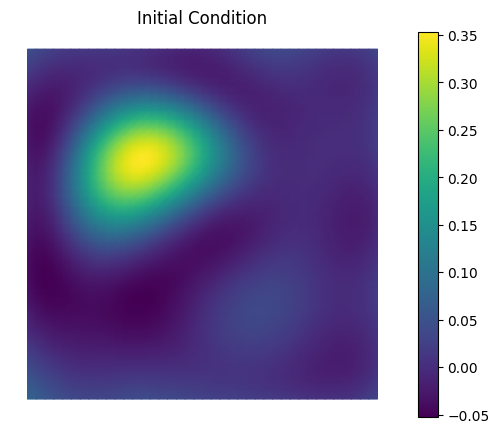

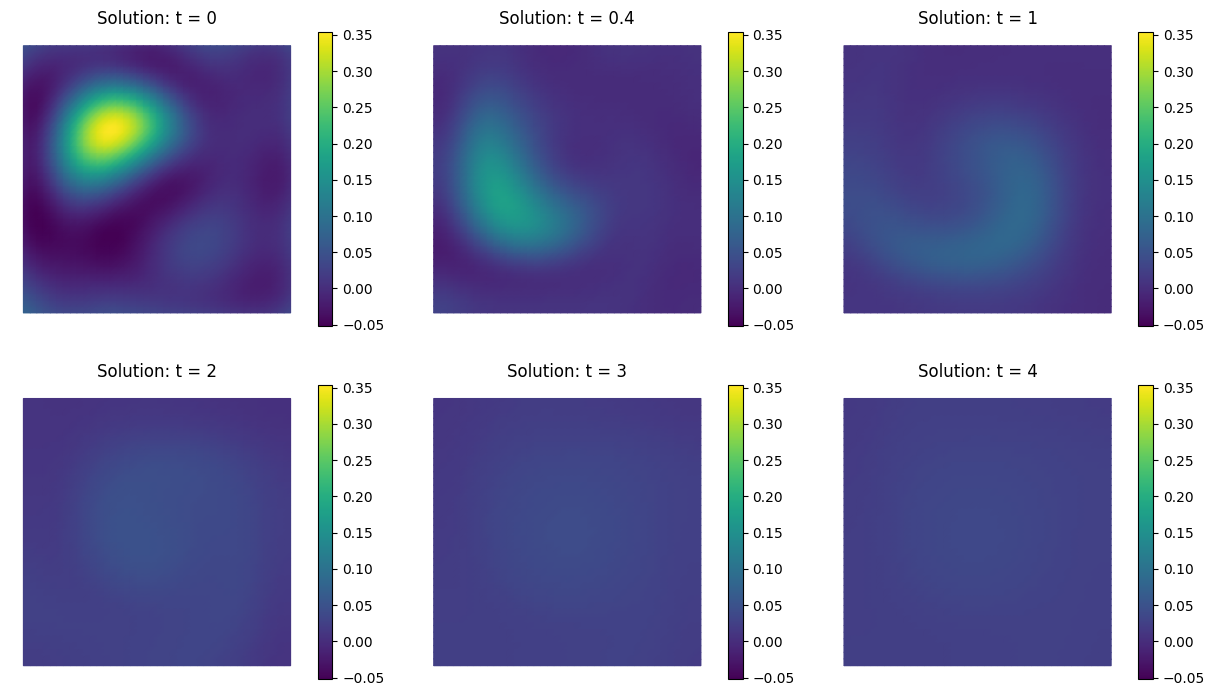

In [9]:
H.misfit_only = False

solver = hm.CGSolverSteihaug(hm.CGSolverSteihaug_ParameterList(), comm)
solver.set_operator(H)
solver.set_preconditioner(posterior.Hlr)
solver.parameters["print_level"] = 1
solver.parameters["rel_tolerance"] = 1e-6
solver.solve(m, -mg)
model.solveFwd(u, [u, m, p])

total_cost, reg_cost, misfit_cost = model.cost([u, m, p])
print("Total cost {0:5g}; Reg Cost {1:5g}; Misfit {2:5g}".format(total_cost, reg_cost, misfit_cost))

posterior.mean = m

plt.figure(figsize=(7.5, 5))
nb.plot(Vh, m, mytitle="Initial Condition")
plt.show()

nb.show_solution(Vh, m, u, mytitle="Solution")
plt.show()

## 10. Prior and posterior pointwise variance fields

Posterior trace 0.000354848; Prior trace 0.0103966; Correction trace 0.0100418


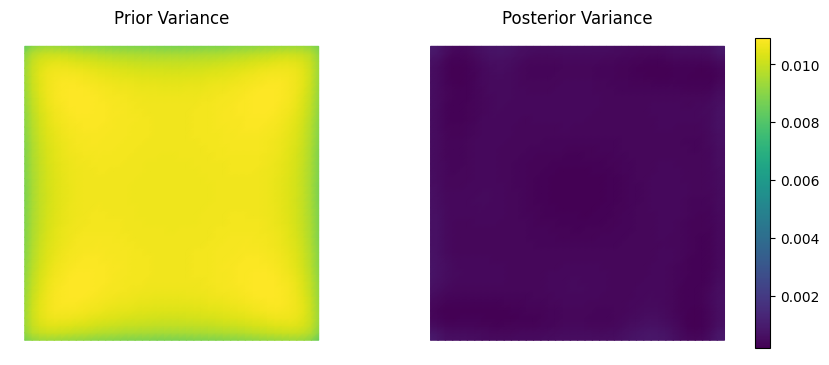

In [10]:
compute_trace = True
if compute_trace:
    post_tr, prior_tr, corr_tr = posterior.trace(method="Randomized", r=300)
    print("Posterior trace {0:5g}; Prior trace {1:5g}; Correction trace {2:5g}".format(post_tr, prior_tr, corr_tr))
post_pw_variance, pr_pw_variance, corr_pw_variance = posterior.pointwise_variance(method="Randomized", r=300)

nb.multi1_plot([(Vh, pr_pw_variance), (Vh, post_pw_variance)],
               ["Prior Variance", "Posterior Variance"], logscale=False)
plt.show()

## 11. Draw samples from the prior and posterior distributions

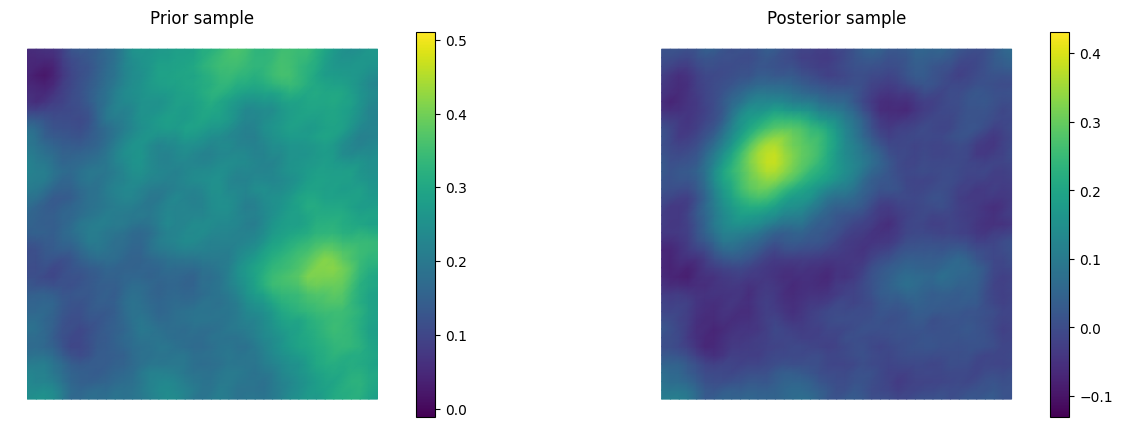

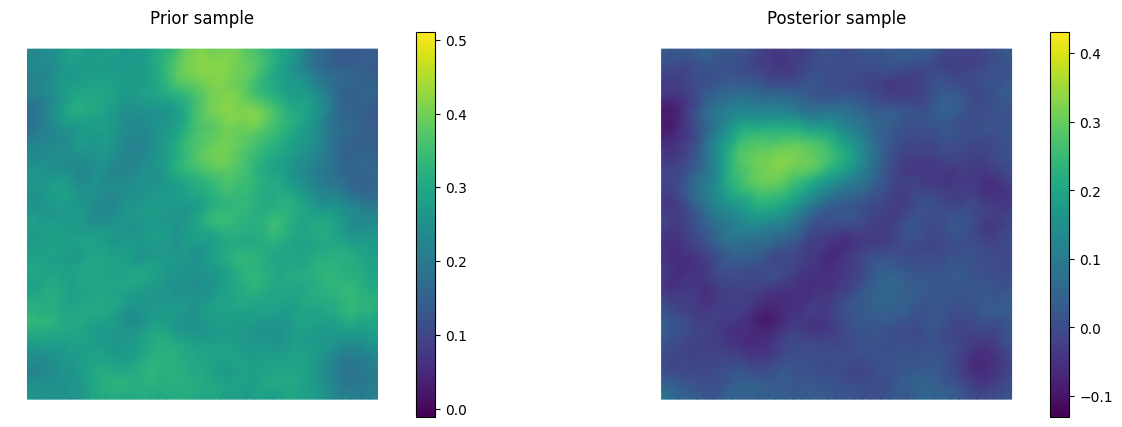

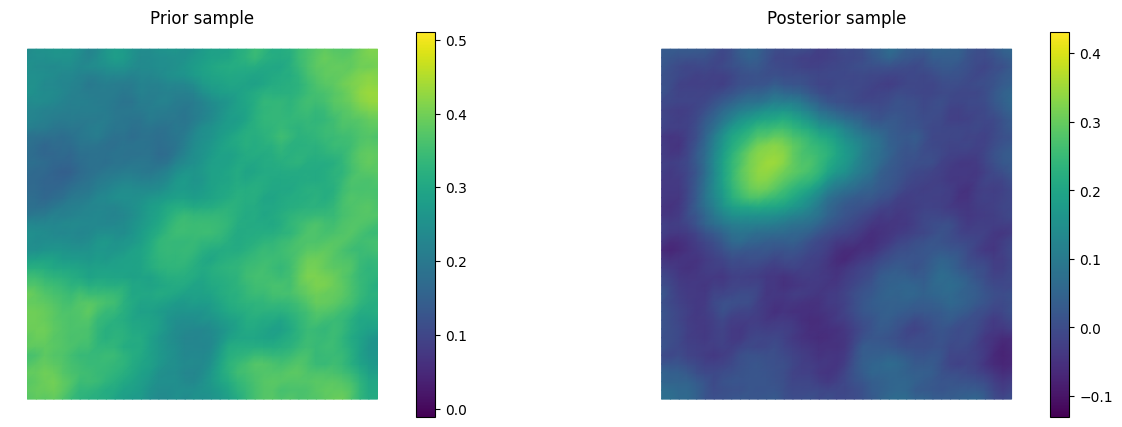

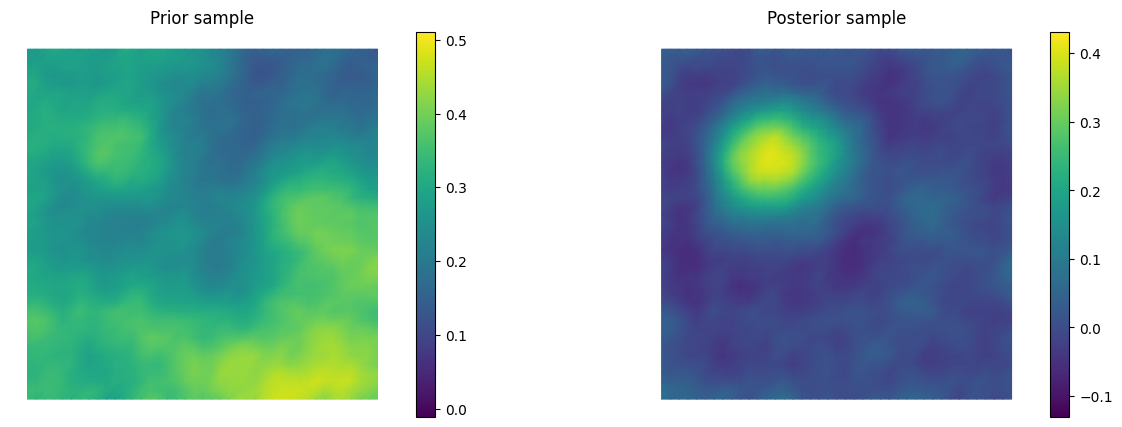

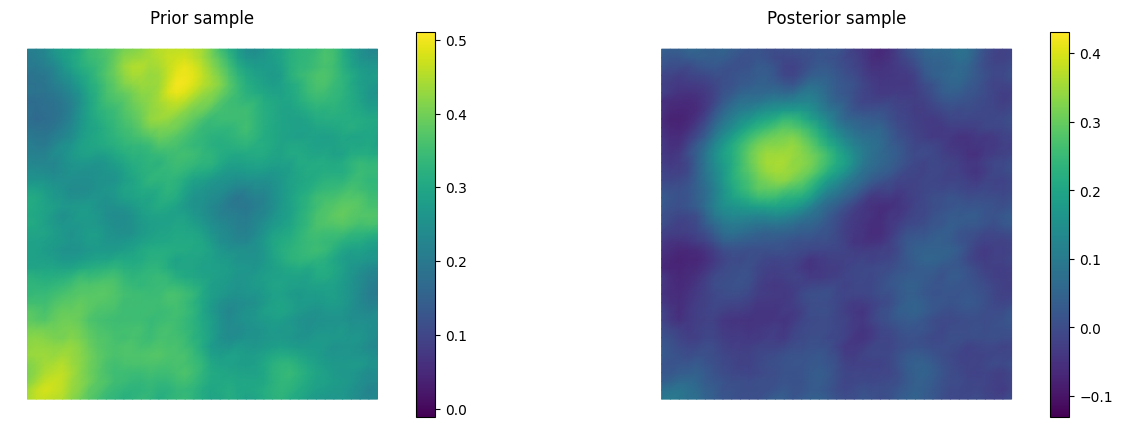

In [11]:
nsamples = 5
noise = prior.noise_vector()
s_prior = Vh.vector()
s_post = Vh.vector()

pr_max = 2.5 * math.sqrt(pr_pw_variance.max()) + prior.mean.max()
pr_min = -2.5 * math.sqrt(pr_pw_variance.max()) + prior.mean.min()
ps_max = 2.5 * math.sqrt(post_pw_variance.max()) + posterior.mean.max()
ps_min = -2.5 * math.sqrt(post_pw_variance.max()) + posterior.mean.min()

for i in range(nsamples):
    prior.sample_noise(1.0, noise)
    posterior.sample(noise, s_prior, s_post)
    plt.figure(figsize=(15, 5))
    nb.plot(Vh, s_prior, subplot_loc=121, mytitle="Prior sample", vmin=pr_min, vmax=pr_max)
    nb.plot(Vh, s_post, subplot_loc=122, mytitle="Posterior sample", vmin=ps_min, vmax=ps_max)
    plt.show()

*Adapted for hIPPyMFEM from hIPPYlib's tutorial `04_AdvectionDiffusionBayesian`.*

Copyright (c) 2016-2018, The University of Texas at Austin & University of California, Merced.<br>
Copyright (c) 2019-2022, The University of Texas at Austin, University of California--Merced, Washington University in St. Louis.<br>
Copyright (c) 2023-, The University of Texas at Austin, University of California--Merced.<br>
Copyright (c) 2026, Peng Chen, Georgia Institute of Technology.<br>
See file COPYRIGHT for details.

This file is part of hIPPyMFEM, free software under the GNU General Public License
version 2.0 dated June 1991 (GPL-2.0-only). hIPPyMFEM follows the programming model
of [hIPPYlib](https://hippylib.github.io).